<a href="https://colab.research.google.com/github/PreethiR091/Deep-Learning/blob/main/Preethi_R_24BAD091_DL_Ex_no_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPT NO: 2 - COMPARATIVE STUDY OF ACTIVATION FUNCTIONS AND OPTIMIZATION ALGORITHMS IN DEEP LEARNING

Task A: VISUALIZATION OF ACTIVATION FUNCTIONS

Implement and plot the following activation functions:

    •	Sigmoid
    •	Tanh
    •	ReLU

Compare their:

    •	Output range
    •	Saturation regions
    •	Gradient behavior
    •	Computational efficiency
    •	Typical applications



Preethi R 24BAD091 



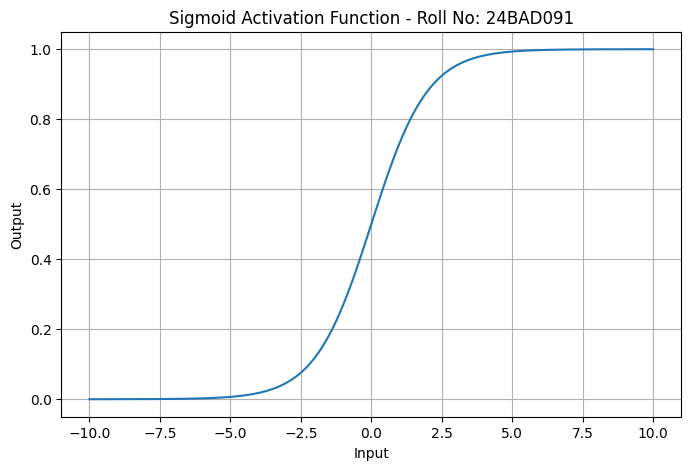

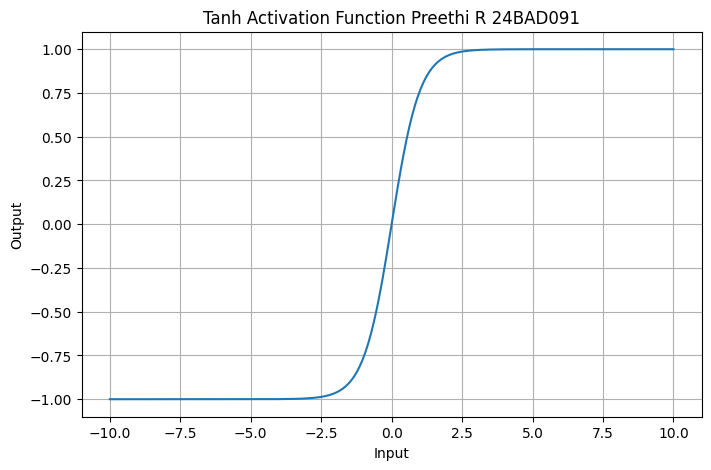

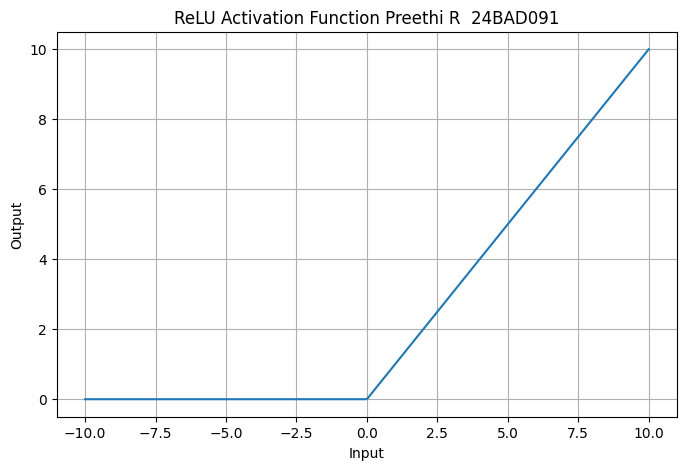

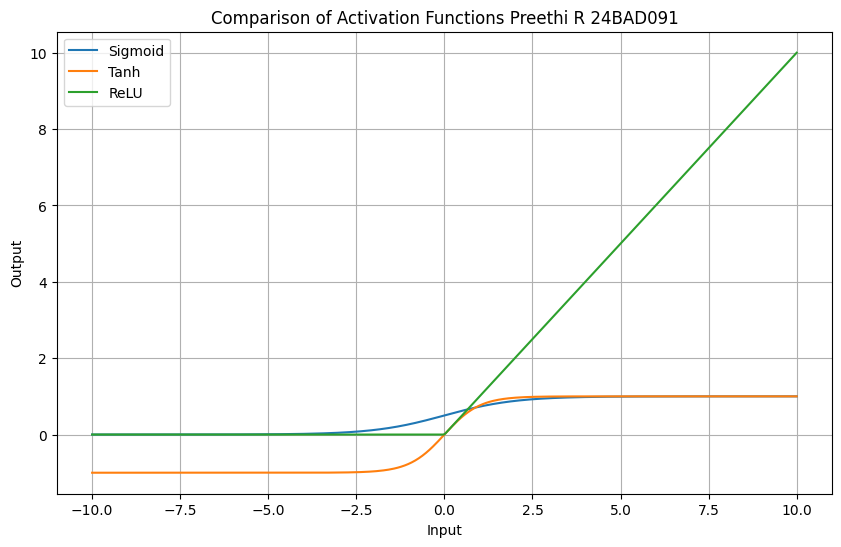

In [ ]:
# EXPERIMENT NO: 2
# TASK A - VISUALIZATION OF ACTIVATION FUNCTIONS
print("Preethi R 24BAD091 \n")

import numpy as np
import matplotlib.pyplot as plt

# Input values
x = np.linspace(-10, 10, 400)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

# Calculate outputs
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)

# Plot Sigmoid
plt.figure(figsize=(8, 5))
plt.plot(x, y_sigmoid)
plt.title("Sigmoid Activation Function - Roll No: 24BAD091")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

# Plot Tanh
plt.figure(figsize=(8, 5))
plt.plot(x, y_tanh)
plt.title("Tanh Activation Function Preethi R 24BAD091")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

# Plot ReLU
plt.figure(figsize=(8, 5))
plt.plot(x, y_relu)
plt.title("ReLU Activation Function Preethi R  24BAD091")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

# Combined comparison
plt.figure(figsize=(10, 6))
plt.plot(x, y_sigmoid, label="Sigmoid")
plt.plot(x, y_tanh, label="Tanh")
plt.plot(x, y_relu, label="ReLU")
plt.title("Comparison of Activation Functions Preethi R 24BAD091")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)
plt.show()

Task B: PERFORMANCE COMPARISON OF ACTIVATION FUNCTIONS

Train identical ANN architectures using:

    •	Sigmoid
    •	Tanh
    •	ReLU

Record and compare:

    •	Training accuracy
    •	Validation accuracy
    •	Training loss
    •	Validation loss
    •	Number of epochs required for convergence

Analyze which activation function performs best and justify the observations.


Preethi R 24BAD091 


Training model with: sigmoid


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7898 - loss: 0.9071 - val_accuracy: 0.9063 - val_loss: 0.3679
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9146 - loss: 0.3120 - val_accuracy: 0.9298 - val_loss: 0.2482
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9338 - loss: 0.2314 - val_accuracy: 0.9436 - val_loss: 0.2011
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9455 - loss: 0.1881 - val_accuracy: 0.9513 - val_loss: 0.1728
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9546 - loss: 0.1578 - val_accuracy: 0.9569 - val_loss: 0.1528
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9614 - loss: 0.1344 - val_accuracy: 0.9604 - val_loss: 0.1377
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9670 - loss: 0.1154 - val_accuracy: 0.9640 - val_loss: 0.1261
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9722 - loss: 0.0997 - val_accuracy: 0.

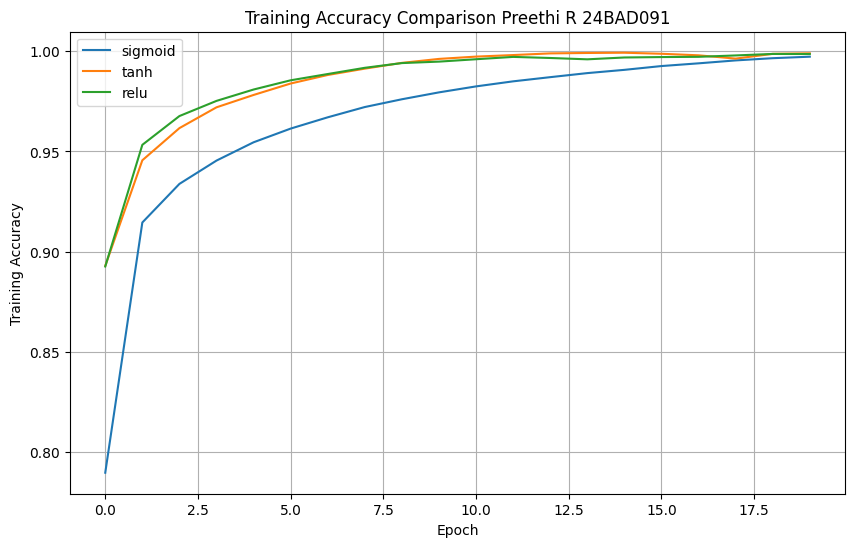

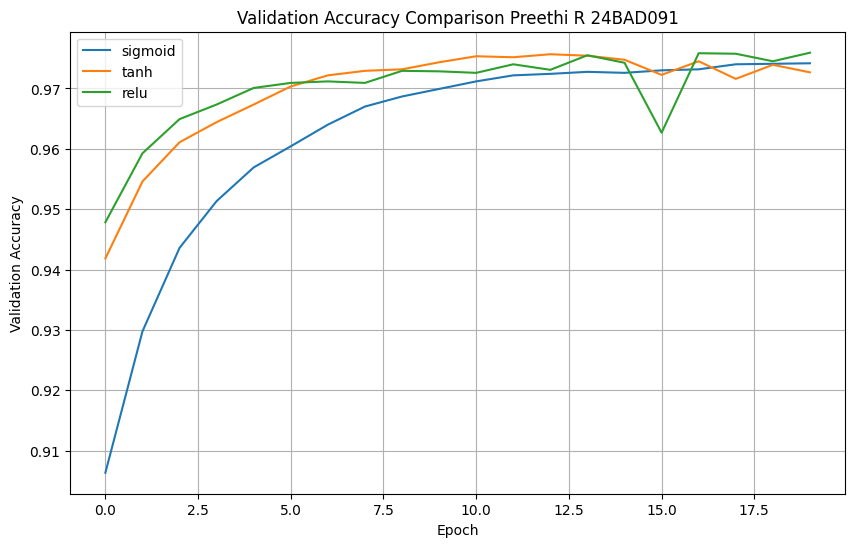

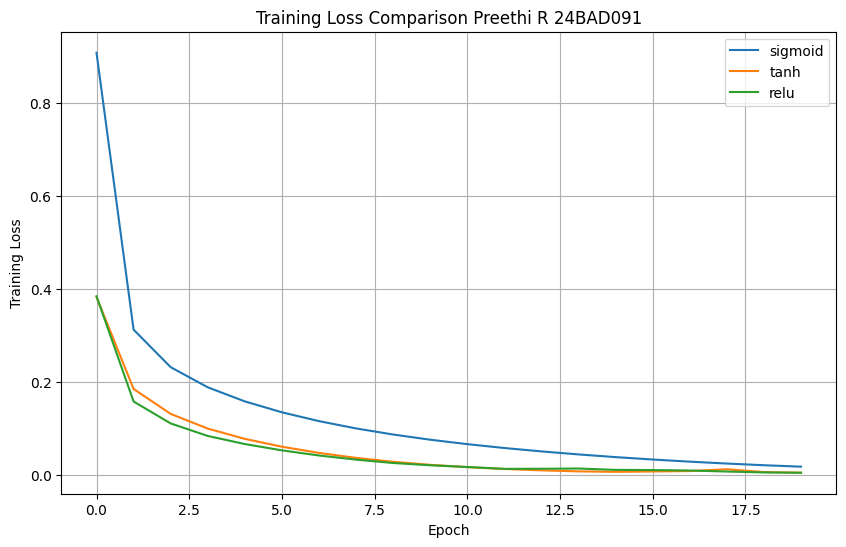

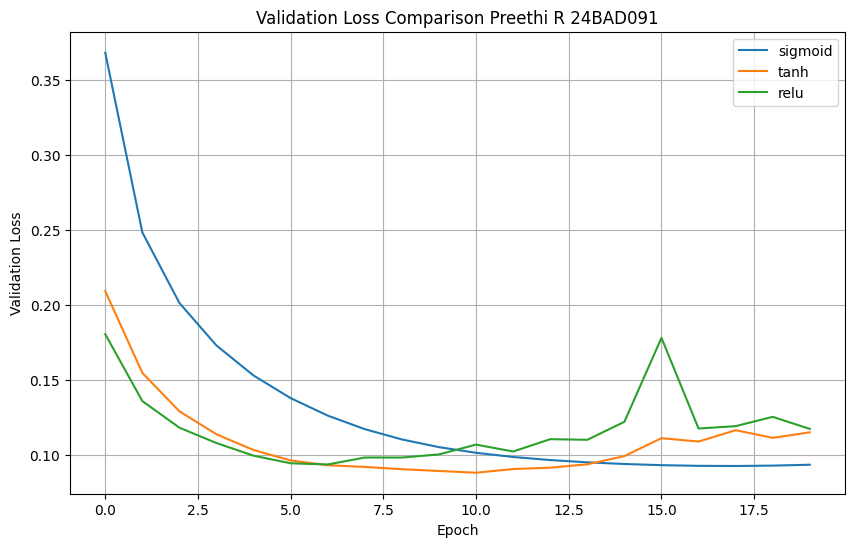

In [6]:
# EXPERIMENT NO: 2
# TASK B - PERFORMANCE COMPARISON OF ACTIVATION FUNCTIONS
print("Preethi R 24BAD091 \n")

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Function to create ANN
def create_model(activation):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=activation),
        Dense(64, activation=activation),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Activation functions
activations = ["sigmoid", "tanh", "relu"]

histories = {}
results = {}

# Train models
for activation in activations:

    print("\nTraining model with:", activation)

    model = create_model(activation)

    history = model.fit(
        x_train,
        y_train,
        epochs=20,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    histories[activation] = history

    # Evaluate test data
    test_loss, test_accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    results[activation] = {
        "Training Accuracy": history.history["accuracy"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1],
        "Training Loss": history.history["loss"][-1],
        "Validation Loss": history.history["val_loss"][-1],
        "Test Accuracy": test_accuracy,
        "Test Loss": test_loss
    }

# Display results
results_df = pd.DataFrame(results).T

print("\nPERFORMANCE COMPARISON")
print(results_df)

# Plot training accuracy
plt.figure(figsize=(10, 6))

for activation in activations:
    plt.plot(
        histories[activation].history["accuracy"],
        label=activation
    )

plt.title("Training Accuracy Comparison Preethi R 24BAD091")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot validation accuracy
plt.figure(figsize=(10, 6))

for activation in activations:
    plt.plot(
        histories[activation].history["val_accuracy"],
        label=activation
    )

plt.title("Validation Accuracy Comparison Preethi R 24BAD091")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot training loss
plt.figure(figsize=(10, 6))

for activation in activations:
    plt.plot(
        histories[activation].history["loss"],
        label=activation
    )

plt.title("Training Loss Comparison Preethi R 24BAD091")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot validation loss
plt.figure(figsize=(10, 6))

for activation in activations:
    plt.plot(
        histories[activation].history["val_loss"],
        label=activation
    )

plt.title("Validation Loss Comparison Preethi R 24BAD091")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Task C: COMPARISON OF OPTIMIZATION ALGORITHMS

Train the same ANN using:

    •	Stochastic Gradient Descent (SGD)
    •	Momentum
    •	RMSProp
    •	Adam

Compare:

    •	Training loss
    •	Validation loss
    •	Convergence speed
    •	Final training accuracy
    •	Final validation accuracy

Visualize:

    •	Loss vs Epoch
    •	Accuracy vs Epoch
    
Discuss which optimizer converges faster and produces better generalization.


Preethi R 24BAD091 


Training with optimizer: SGD
Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6149 - loss: 1.4666 - val_accuracy: 0.8273 - val_loss: 0.7618
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8496 - loss: 0.6024 - val_accuracy: 0.8815 - val_loss: 0.4527
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8833 - loss: 0.4352 - val_accuracy: 0.9000 - val_loss: 0.3685
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8966 - loss: 0.3721 - val_accuracy: 0.9087 - val_loss: 0.3281
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9050 - loss: 0.3366 - val_accuracy: 0.9151 - val_loss: 0.3030
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9114 - loss: 0.3125 - val_accuracy: 0.9190 - val_loss: 0.2849
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9158 - loss: 0.2941 - val_accuracy: 0.9236 - val_loss: 0.2706
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9201 - loss: 0.2791 - val_accuracy: 0.9268 - val_

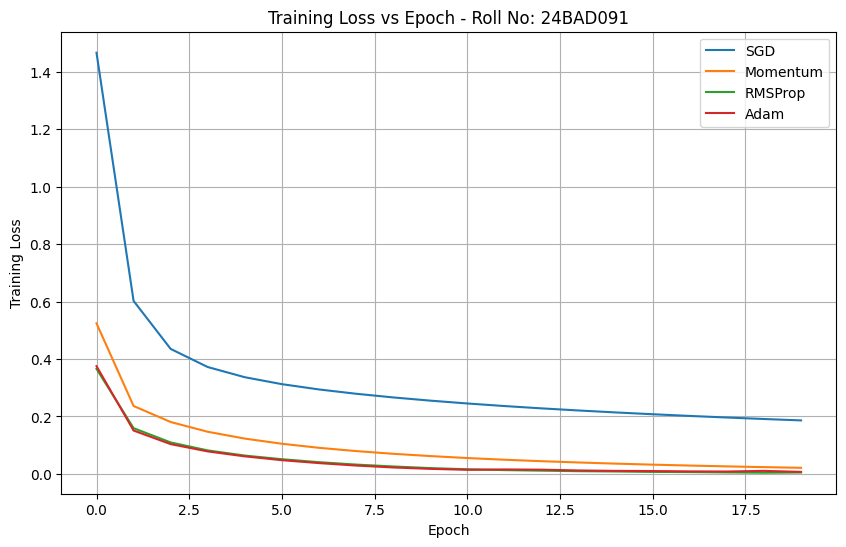

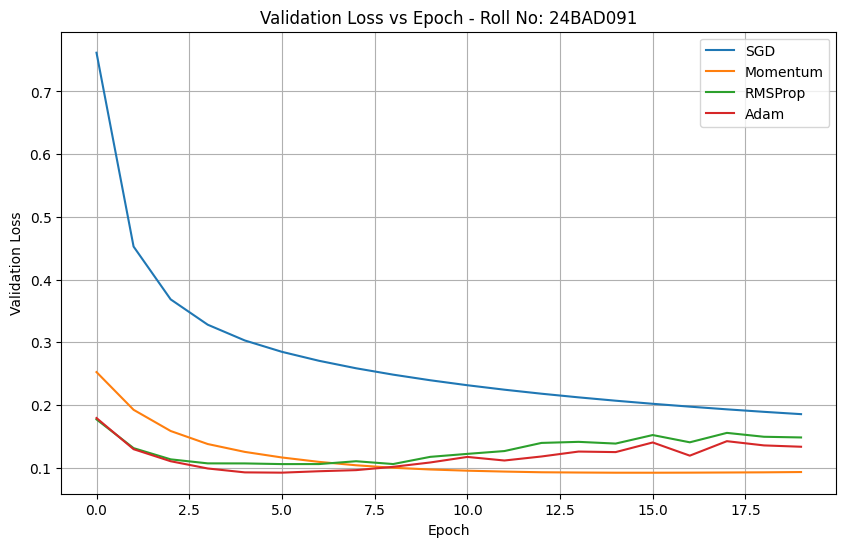

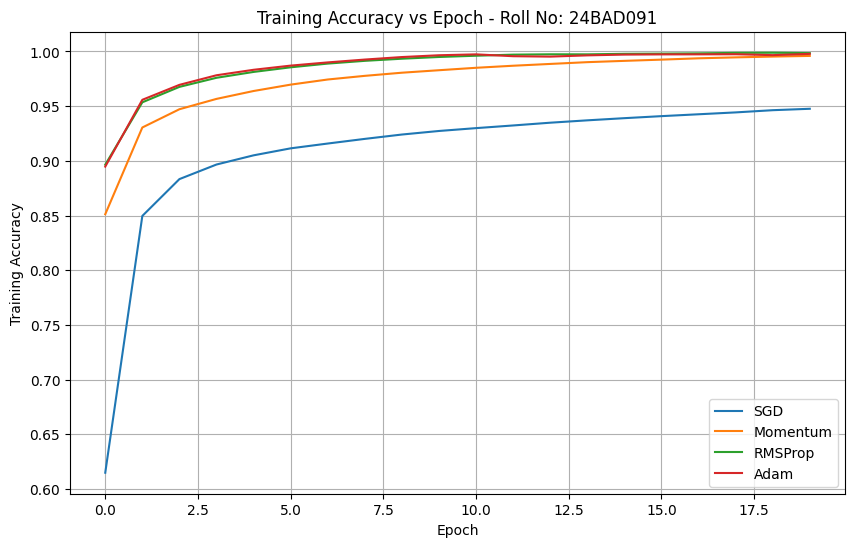

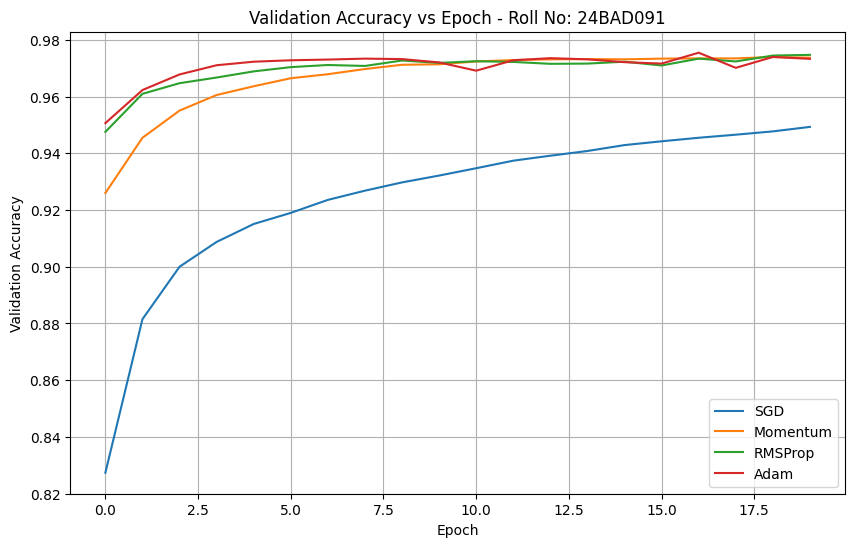

In [7]:
# EXPERIMENT NO: 2
# TASK C - COMPARISON OF OPTIMIZATION ALGORITHMS
print("Preethi R 24BAD091 \n")

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Create model
def create_model(optimizer):

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Define optimizers

optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "RMSProp": RMSprop(learning_rate=0.001),
    "Adam": Adam(learning_rate=0.001)
}

histories = {}
results = {}

# Train models
for name, optimizer in optimizers.items():

    print("\nTraining with optimizer:", name)

    model = create_model(optimizer)

    history = model.fit(
        x_train,
        y_train,
        epochs=20,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    histories[name] = history

    # Evaluate model
    test_loss, test_accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    results[name] = {
        "Training Accuracy": history.history["accuracy"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1],
        "Training Loss": history.history["loss"][-1],
        "Validation Loss": history.history["val_loss"][-1],
        "Test Accuracy": test_accuracy,
        "Test Loss": test_loss
    }

# Display comparison
results_df = pd.DataFrame(results).T

print("\nOPTIMIZER PERFORMANCE COMPARISON")
print(results_df)

# Loss vs Epoch

plt.figure(figsize=(10, 6))

for name in optimizers:
    plt.plot(
        histories[name].history["loss"],
        label=name
    )

plt.title("Training Loss vs Epoch - Roll No: 24BAD091")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

# Validation Loss

plt.figure(figsize=(10, 6))

for name in optimizers:
    plt.plot(
        histories[name].history["val_loss"],
        label=name
    )

plt.title("Validation Loss vs Epoch - Roll No: 24BAD091")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy vs Epoch

plt.figure(figsize=(10, 6))

for name in optimizers:
    plt.plot(
        histories[name].history["accuracy"],
        label=name
    )

plt.title("Training Accuracy vs Epoch - Roll No: 24BAD091")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Validation Accuracy

plt.figure(figsize=(10, 6))

for name in optimizers:
    plt.plot(
        histories[name].history["val_accuracy"],
        label=name
    )

plt.title("Validation Accuracy vs Epoch - Roll No: 24BAD091")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Task D: DEEP LEARNING EXPERIMENT MANAGEMENT

Perform the following tasks:

    •	Create a Google Colab notebook.
    •	Mount Google Drive.
    •	Save notebooks and trained models.
    •	Create a GitHub repository.
    •	Upload notebooks to GitHub.
    •	Commit changes and maintain version history using Git.
    •	Document the experiment using a README.md file.



In [10]:
# EXPERIMENT NO: 2
# TASK D: DEEP LEARNING EXPERIMENT MANAGEMENT
# Student Name: Preethi R
# Roll No: 24BAD091

print("Preethi R - 24BAD091")

# Import required libraries
import os
import json
import tensorflow as tf

print("\nTensorFlow Version:", tf.__version__)

# Mount Google Drive
drive_mounted = False

try:
    from google.colab import drive

    print("\nMounting Google Drive...")
    drive.mount("/content/drive", force_remount=True)

    if os.path.exists("/content/drive/MyDrive"):
        drive_mounted = True
        print("Google Drive mounted successfully.")
    else:
        print("Google Drive was not detected.")

except Exception as e:
    print("Google Drive mounting was unsuccessful.")
    print("Error:", str(e))

# Set storage location
if drive_mounted:
    base_path = "/content/drive/MyDrive/Deep_Learning_Experiment_2_24BAD091"
else:
    base_path = "/content/Deep_Learning_Experiment_2_24BAD091"

# Create folders
notebook_folder = os.path.join(base_path, "Notebooks")
model_folder = os.path.join(base_path, "Models")
result_folder = os.path.join(base_path, "Results")

os.makedirs(notebook_folder, exist_ok=True)
os.makedirs(model_folder, exist_ok=True)
os.makedirs(result_folder, exist_ok=True)

print("\nExperiment folders created successfully.")
print("Base Folder:", base_path)
print("Notebooks:", notebook_folder)
print("Models:", model_folder)
print("Results:", result_folder)

# Create a sample ANN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential([
    Input(shape=(10,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nANN model created successfully.")

# Save the trained model
model_path = os.path.join(
    model_folder,
    "experiment2_model.keras"
)

model.save(model_path)

print("Model saved successfully.")
print("Model path:", model_path)

# Verify the saved model
if os.path.exists(model_path):
    print("Model verification: SUCCESS")
else:
    print("Model verification: FAILED")

# Create experiment documentation
experiment_info = {
    "student_name": "Preethi R",
    "roll_number": "24BAD091",
    "experiment": "Comparative Study of Activation Functions and Optimization Algorithms in Deep Learning",
    "activation_functions": [
        "Sigmoid",
        "Tanh",
        "ReLU"
    ],
    "optimization_algorithms": [
        "SGD",
        "Momentum",
        "RMSProp",
        "Adam"
    ],
    "tools": [
        "Python",
        "TensorFlow",
        "Google Colab",
        "Google Drive",
        "GitHub",
        "Matplotlib"
    ],
    "tasks": [
        "Visualization of Activation Functions",
        "Performance Comparison of Activation Functions",
        "Comparison of Optimization Algorithms",
        "Deep Learning Experiment Management"
    ]
}

info_path = os.path.join(
    result_folder,
    "experiment_info.json"
)

with open(info_path, "w") as file:
    json.dump(experiment_info, file, indent=4)

print("\nExperiment documentation saved.")
print("Documentation path:", info_path)

# Create README.md
readme_content = """# Deep Learning Experiment 2

## Student Details

Name: Preethi R
Roll No: 24BAD091

## Experiment

Comparative Study of Activation Functions and Optimization Algorithms in Deep Learning

## Activation Functions

- Sigmoid
- Tanh
- ReLU

## Optimization Algorithms

- SGD
- Momentum
- RMSProp
- Adam

## Tools Used

- Python
- TensorFlow
- Google Colab
- Google Drive
- GitHub
- Matplotlib

## Tasks

- Task A: Visualization of Activation Functions
- Task B: Performance Comparison of Activation Functions
- Task C: Comparison of Optimization Algorithms
- Task D: Deep Learning Experiment Management

## Experiment Management

Google Colab was used to execute the deep learning experiments.

Google Drive was used to store notebooks, models, and experiment results.

GitHub was used for version control and maintaining experiment history.

README.md was created to document the experiment.
"""

readme_path = os.path.join(
    base_path,
    "README.md"
)

with open(readme_path, "w") as file:
    file.write(readme_content)

print("\nREADME.md created successfully.")
print("README path:", readme_path)

# Display saved files
print("\nSaved Files")
print("=" * 60)

for root, dirs, files in os.walk(base_path):
    for file in files:
        print(os.path.join(root, file))

# Display final status
print("\nTask D Status")
print("=" * 60)

print("Google Drive       :", "SUCCESS" if drive_mounted else "NOT MOUNTED")
print("Experiment Folder  : SUCCESS")
print("ANN Model          : SUCCESS")
print("Model Saved        : SUCCESS")
print("Documentation      : SUCCESS")
print("README.md          : SUCCESS")
print("GitHub             : Upload notebook and README")
print("Git Version Control: Add commits and maintain history")

print("\nTask D execution completed successfully.")

Preethi R - 24BAD091

TensorFlow Version: 2.20.0

Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted successfully.

Experiment folders created successfully.
Base Folder: /content/drive/MyDrive/Deep_Learning_Experiment_2_24BAD091
Notebooks: /content/drive/MyDrive/Deep_Learning_Experiment_2_24BAD091/Notebooks
Models: /content/drive/MyDrive/Deep_Learning_Experiment_2_24BAD091/Models
Results: /content/drive/MyDrive/Deep_Learning_Experiment_2_24BAD091/Results

ANN model created successfully.
Model saved successfully.
Model path: /content/drive/MyDrive/Deep_Learning_Experiment_2_24BAD091/Models/experiment2_model.keras
Model verification: SUCCESS

Experiment documentation saved.
Documentation path: /content/drive/MyDrive/Deep_Learning_Experiment_2_24BAD091/Results/experiment_info.json

README.md created successfully.
README path: /content/drive/MyDrive/Deep_Learning_Experiment_2_24BAD091/README.md

Saved Files
/content/drive/MyDrive/Deep_Learning_Experiment_2_24BAD091/REA